<a href="https://colab.research.google.com/github/julmiha25-sys/MathStatistica/blob/main/%D0%98%D1%82%D0%BE%D0%B3%D0%BE%D0%B2%D1%8B%D0%B9_%D0%BF%D1%80%D0%BE%D0%B5%D0%BA%D1%82_%D0%BF%D0%BE_%D0%BB%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%BE%D0%B9_%D0%BA%D0%BE%D0%BC%D0%BF%D0%B0%D0%BD%D0%B8%D0%B8/%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B0_%D0%BB%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%BE%D0%B9_%D0%BA%D0%BE%D0%BC%D0%BF%D0%B0%D0%BD%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Статистика выборки за весь период - количество заказов по клиентам

Медиана:3.0, 
Среднее:23.876697447039653, 
Мода:1, 
Ср.квадратичное отклонение:161.79139650756977, 
Коэф.асимметрии:21.87870620227133,, 
Коэф.эксцесса:587.7599032134736
Максимум заказов: 4999 , Минимум заказов: 1
МаксДата: 2016-12-01 , МинДата: 2015-01-01

Гистограмма распределения для выборки


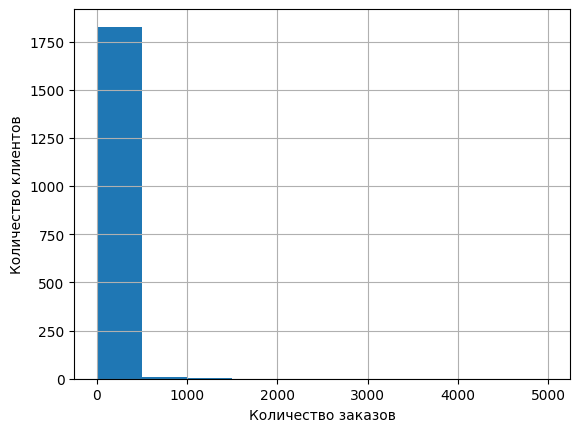

Гистограмма распределения для выборки за 2016 год


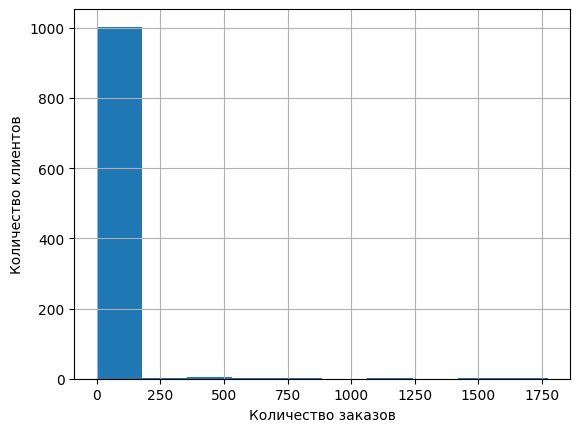

График квантилей  для выборки


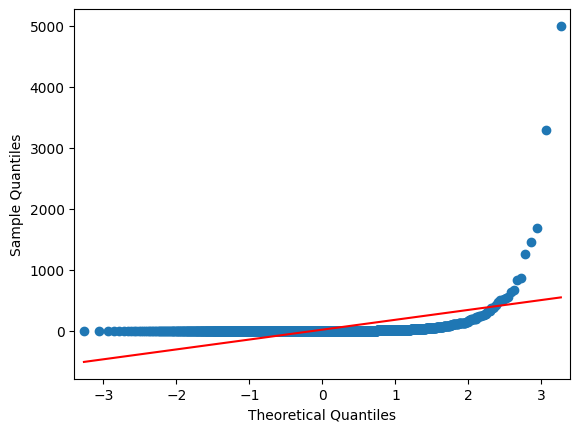

График квантилей  для выборки за 2016 год


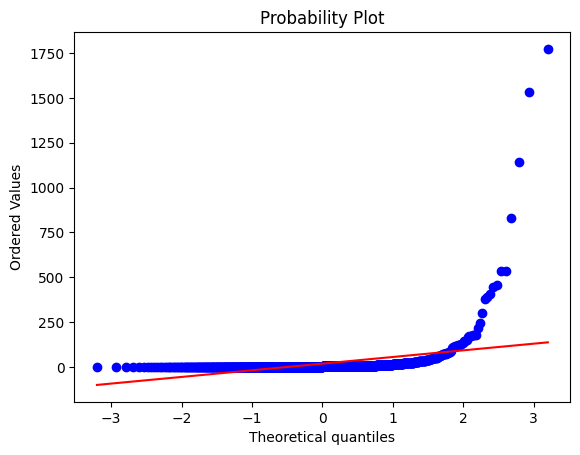

Длина выборки: 1841
Длина выборки за 2016 год: 1017
Критерий нормальности Шапиро-Франчиа: ShapiroResult(statistic=np.float64(0.09870431503788013), pvalue=np.float64(7.678448800188936e-69))
Критерий нормальности Шапиро-Франчиа за 2016 год: ShapiroResult(statistic=np.float64(0.1519145536676807), pvalue=np.float64(3.328689735362214e-55))
Критерий проверки на симметричность: SkewtestResult(statistic=np.float64(57.427113001417254), pvalue=np.float64(0.0))
Критерий проверки на симметричность за 2016 год: SkewtestResult(statistic=np.float64(37.17713461862894), pvalue=np.float64(1.598109522464613e-302))
Критерий проверки на остроту пика: 586.1615532424598, нормальный KurtosistestResult(statistic=np.float64(31.074457303633626), pvalue=np.float64(5.332823828246278e-212))
Критерий проверки на остроту пика за 2016 год: 194.47157069529993, нормальный KurtosistestResult(statistic=np.float64(21.89989550611709), pvalue=np.float64(2.6037709534678033e-106))
Критерий К-квадрат Д'Агостино: NormaltestResul

In [79]:
#	Анализ клиентов по объему заказов
# Проверка нормальности распределения количества заказов по клиентам за весь период (2015-2016) и за 2016 год отдельно.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import probplot
import scipy.stats as stats
Orders = pd.read_excel('Логистическая_компания.xlsx', sheet_name='Исходные_данные')
# Преобразование дат
months = {
    'января': 'January', 'февраля': 'February', 'марта': 'March',
    'апреля': 'April', 'мая': 'May', 'июня': 'June',
    'июля': 'July', 'августа': 'August', 'сентября': 'September',
    'октября': 'October', 'ноября': 'November', 'декабря': 'December'
}
date_str = Orders['ГодМесяц'].astype(str)
for ru, en in months.items():
    date_str = date_str.str.replace(ru, en)
Orders['ГодМесяц'] = pd.to_datetime(date_str, format='%d %B %Y г.', errors='coerce').dt.date
# Выборка за весь период
df=Orders.groupby(['Клиент','Год'])['Номер ПП'].count().reset_index(name='Количество')
df0=Orders.groupby(['Клиент'])['Номер ПП'].count().reset_index(name='Количество')
df1=df0['Количество']
# Выборка за 2016 год
df2=df[df['Год'] == 2016]['Количество']

# Статистические характеристики для всей выборки
print("Статистика выборки за весь период - количество заказов по клиентам\n")
print(f"Медиана:{df1.median()}, \nСреднее:{df1.mean()}, \nМода:{df1.mode().iloc[0]}, \nСр.квадратичное отклонение:{df1.std()}, \nКоэф.асимметрии:{df1.skew()},, \nКоэф.эксцесса:{df1.kurtosis()}")
print(f"Максимум заказов: {df1.max()} , Минимум заказов: {df1.min()}")
print(f"МаксДата: {Orders['ГодМесяц'].max()} , МинДата: {Orders['ГодМесяц'].min()}")
# У нормального распределения среднее, медиана и мода должны быть близки - у нас нет, среднее 17.58, медиана 3, мода 1.
# Ср.квадратичное отклонение 101.9 - очень большое
# Коэф.ассим. 19.39 > 0 - у распределения правый хвост длиннее

# Гистограмма распределения - не похоже на нормальное распределение - правый хвост длинный
print("\nГистограмма распределения для выборки")
df1.hist(bins=10)
plt.xlabel('Количество заказов')
plt.ylabel('Количество клиентов')
plt.show()
print("Гистограмма распределения для выборки за 2016 год")
df2.hist(bins=10)
plt.xlabel('Количество заказов')
plt.ylabel('Количество клиентов')
plt.show()

# График квантилей - отклонение от нормального вида слишком большие
print("График квантилей  для выборки")
qqplot(df1, line='s')
plt.show()
# График квантилей за 2016 год - отклонение от нормального вида слишком большие
print("График квантилей  для выборки за 2016 год")
stats.probplot(df2, dist="norm", plot=plt)
plt.show()

print(f"Длина выборки: {len(df1)}")
print(f"Длина выборки за 2016 год: {len(df2)}")

# Длина выборки < 5000 - критерий Шапиро-Уилка - Шапиро-Франчиа
from scipy.stats import shapiro
print(f"Критерий нормальности Шапиро-Франчиа: {shapiro(df1)}")
# p=0 < a=0.05 - гипотезу о нормальности выборки отвергаем на уровне значимости α = 0.05.
print(f"Критерий нормальности Шапиро-Франчиа за 2016 год: {shapiro(df2)}")
# p=0 < a=0.05 - гипотезу о нормальности выборки за 2016 год отвергаем на уровне значимости α = 0.05.

# Критерий проверки на симметричность
from scipy.stats import *
print(f"Критерий проверки на симметричность: {skewtest(df1)}")
# p=0 < a=0.05 - гипотезу о нормальности выборки отвергаем на уровне значимости α = 0.05.
print(f"Критерий проверки на симметричность за 2016 год: {skewtest(df2)}")
# p=0 < a=0.05 - гипотезу о нормальности выборки за 2016 год отвергаем на уровне значимости α = 0.05.

# Критерий проверки на остроту пика
print(f"Критерий проверки на остроту пика: {kurtosis(df1)}, нормальный {kurtosistest(df1)}")
# p=0 < a=0.05 - гипотезу о нормальности выборки отвергаем на уровне значимости α = 0.05.
print(f"Критерий проверки на остроту пика за 2016 год: {kurtosis(df2)}, нормальный {kurtosistest(df2)}")
# p=0 < a=0.05 - гипотезу о нормальности выборки за 2016 год отвергаем на уровне значимости α = 0.05.

# Критерий К-квадрат Д'Агостино
print(f"Критерий К-квадрат Д'Агостино: {normaltest(df1)}")
# p=0 < a=0.05 - гипотезу о нормальности выборки отвергаем на уровне значимости α = 0.05.
print(f"Критерий К-квадрат Д'Агостино за 2016 год: {normaltest(df2)}")
# p=0 < a=0.05 - гипотезу о нормальности выборки за 2016 год отвергаем на уровне значимости α = 0.05.

# Тест Андерсона-Дарлинга
print(f"Тест Андерсона-Дарлинга:{anderson(df1)}")
# statistic=559.02 > 0.785 из critical_values=array([0.575, 0.655, 0.785, 0.916, 1.09 ]), соответствующие уровню значимости 0.05 - гипотезу о нормальности выборки отвергаем
print(f"Тест Андерсона-Дарлинга за 2016 год:{anderson(df2)}")
# statistic=295.6 > 0.784 из critical_values=array([0.574, 0.653, 0.784, 0.914, 1.088]), соответствующие уровню значимости 0.05 - гипотезу о нормальности выборки отвергаем

# Одновыборочный критерий Колмогорова-Смирнова
mean=df1.mean()
std=df1.std()
print(f"Одновыборочный критерий Колмогорова-Смирнова:{ks_1samp(df1, norm.cdf, args=(mean, std))}")
# p=0 < a=0.05 - гипотезу о нормальности выборки отвергаем на уровне значимости α = 0.05.
mean=df2.mean()
std=df2.std()
print(f"Одновыборочный критерий Колмогорова-Смирнова за 2016 год:{ks_1samp(df2, norm.cdf, args=(mean, std))}")
# p=0 < a=0.05 - гипотезу о нормальности выборки за 2016 год отвергаем на уровне значимости α = 0.05.

# Результаты:
# Среднее (23.88) значительно превышает медиану (3.0) и моду (1)
# Коэффициент асимметрии = 21.88 (сильный правый хвост)
# Коэффициент эксцесса = 587.76 (очень острый пик)
# Все критерии нормальности (Шапиро-Уилка, Д'Агостино, Андерсона-Дарлинга, Колмогорова-Смирнова) дают p-value < 0.05.
# Вывод:
# Распределение количества заказов по клиентам не является нормальным как за весь период, так и за 2016 год.
# Наблюдается сильная правосторонняя асимметрия: большинство клиентов совершают 1-3 заказа, при этом есть небольшое число клиентов с очень большим количеством заказов (максимум 4999).
# Такое распределение характерно для многих бизнес-показателей.
# ТОП-5 корпоративных клиентов
top5_clients = (Orders.groupby('Клиент')['Номер ПП']
                .count()
                .reset_index(name='Общее кол-во заказов')
                .sort_values('Общее кол-во заказов', ascending=False)
                .head(5))
print("\nТОП-5 корпоративных клиентов за весь период:")
print(top5_clients.to_string(index=False))
# Ненормальное распределение (с длинным правым хвостом) означает несколько крупных клиентов дают 80% выручки - компания ориентирована не на массовых, а на корпоративных клиентов.

Матрица распределения заказов менеджеров по филиалам

Филиал       Березники  Москва  Нижневартовск  Пермь  Санкт-Петербург  Сургут  Тюмень
Менеджер                                                                             
Барашкин             2       9             20     58              820      29      85
Бетин                2       3             19     30              536      30      37
Варфаламеев         17      12             20     77             1255      29     171
Виноградов          16      21             31    195             1913     119     243
Машков              30      45             78    195             2600     135     358
Санников            10       9             22     51             1361      67     154
Скоморохов          13      24             38    155             2580     104     248
Фокина              19      10             34     69             1438      76     137
Шубина               9      14             16     88             1512      95     126


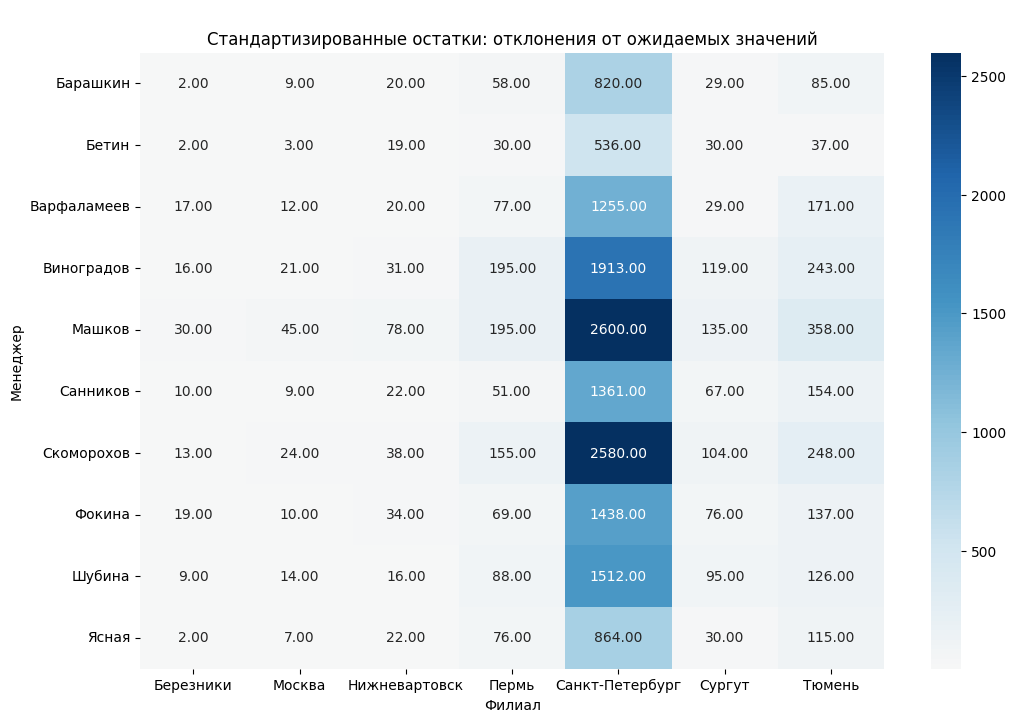

In [68]:
# Анализ деятельности менеджеров в разрезе филиалов
# Анализ качественных данных
# Определение зависимости между менеджером и филиалом за 2016 год
import pandas as pd
import numpy as np
from math import *
import scipy.stats
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

Orders = pd.read_excel('Логистическая_компания.xlsx', sheet_name='Исходные_данные')
Orders = Orders.dropna()
# Дубликаты по полю "Номер_ПП" не удаляем, т.к. внутри одного заказа могут быть 2 заказа - попутная загрузка
count = Orders[Orders['Год']==2016].groupby(['Менеджер', 'Филиал'])['Менеджер'].count().unstack()
count = count.fillna(0)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 20)
# Критерий согласия хи-квадрат Пирсона
print(f"Матрица распределения заказов менеджеров по филиалам\n\n{count}\n\nДостигнутый уровень значимости (фактическая вероятность) p_value: {chi2_contingency(count)[1]}")
# pvalue=0 < 0.05 - гипотезу о независимости менеджера от филиала отвергаем
# H0: гипотеза о статистической независимости между менеджером и филиалом отвергается на уровне значимости α = 0.05.

# Анализ тепловой карты
plt.figure(figsize=(12, 8))
sns.heatmap(count, annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title('\nСтандартизированные остатки: отклонения от ожидаемых значений')
plt.xlabel('Филиал')
plt.ylabel('Менеджер')
plt.show()
# Менеджеры демонстрируют статистически значимый дефицит заказов во всех филиалах, за исключением Санкт-Петербурга.
# Это может свидетельствовать о региональных особенностях рынка, необходимости усиления менеджерского состава в проблемных филиалах.

In [49]:
# Проверка прогноза количества продаж по направлениям бизнеса
# Анализ качественных данных - прогноз
# 2016 году количество продаж по направлениям бизнеса будут распределяться следующим образом:
# Контроль за оборудованием - 47%, Логистика - 1,5%, Международные перевозки - 1,5% и Перевозки по РФ - 50%. Проверим, оправдались ли ожидания.
import pandas as pd
a=[0.47,0.015,0.015,0.50]
Orders = pd.read_excel('Логистическая_компания.xlsx', sheet_name='Исходные_данные')
Orders = Orders.dropna()
Orders = Orders[Orders['Год']==2016]
# Абсолютные наблюдаемые частоты
count = Orders.groupby(['Направление бизнеса'], group_keys=False)['Филиал'].count()
N = count.sum()
# Теоретические абсолютные частоты
expected = [a[i] * N for i in range(len(a))]
contingency_table = [count.values, expected]
print("Наблюдаемые абс.частоты | Теоретические абс.частоты")
for obs, exp in zip(count.values, expected):
    print(f"{obs:>23} | {exp:<20.2f}")
# Критерий согласия хи-квадрат Пирсона
print(f"Достигнутый уровень значимости (фактическая вероятность) p_value: {chi2_contingency(contingency_table)[1]}")
# pvalue=0.26 > 0.05 гипотезу об оправдании ожиданий не отклоняем
# H0: гипотеза об ожидании продаж в 2016 году  не отвергается на уровне значимости α = 0.05.

Наблюдаемые абс.частоты | Теоретические абс.частоты
                   8840 | 8852.45             
                    312 | 282.52              
                    246 | 282.52              
                   9437 | 9417.50             
Достигнутый уровень значимости (фактическая вероятность) p_value: 0.2599165193881559


In [73]:
# Анализ эффективности скидочных акций
# Анализ качественных данных
# В 2015 году проводился тест: выбрали 5 клиентов случайным образом, которые пользовались услугами ранее:
# {'ЮНИ-ТРЕЙД', 'Азимут', 'Афина', 'Белфорт', 'Корунд'}.
# Им предложили 3-и разные скидочные акции: с 1-го кварала, 2-го, 3-го 2015 года.
# Если хотя бы один заказ был совершен, то это успех, если нет, то неудача.
# Оценим, одинаковый ли эффект дали эти акции? Если разный, то между какими акциями наблюдается различие?
import pandas as pd
from statsmodels.stats import contingency_tables
Orders = pd.read_excel('Логистическая_компания.xlsx', sheet_name='Исходные_данные')
s=['ЮНИ-ТРЕЙД', 'КОНО', 'Афина', 'Белфорт', 'Корунд']
Action1 = Orders[(Orders['Квартал']==2) & (Orders['Год']==2015)].groupby('Клиент')['Номер ПП'].count().reset_index(name='Акция1')
Action2 = Orders[(Orders['Квартал']==3) & (Orders['Год']==2015)].groupby('Клиент')['Номер ПП'].count().reset_index(name='Акция2')
Action3 = Orders[(Orders['Квартал']==4) & (Orders['Год']==2015)].groupby('Клиент')['Номер ПП'].count().reset_index(name='Акция3')
All = pd.DataFrame(s, columns=['Клиент'])
All = All.sort_values('Клиент').reset_index(drop=True)
All = All.merge(Action1[['Клиент', 'Акция1']], on='Клиент', how='left')
All = All.merge(Action2[['Клиент', 'Акция2']], on='Клиент', how='left')
All = All.merge(Action3[['Клиент', 'Акция3']], on='Клиент', how='left')
All=All.fillna(0)
All[['Акция1', 'Акция2', 'Акция3']] = All[['Акция1', 'Акция2', 'Акция3']].map(lambda x: 1 if x > 0 else 0)
print("Клиенты с заказами по акциям:\n")
print(All)
# Q-критерий Кохрена
print(f"\nДостигнутый уровень значимости (фактическая вероятность) p_value: {contingency_tables.cochrans_q(All[['Акция1', 'Акция2', 'Акция3']]).pvalue}")
# p_value=0.135 > 0.05 - гипотезу о равенстве акций не отклоняем
# H0: доли клиентов, совершивших хотя бы один заказ, одинаковы для всех 3-х акций (нет различий   в эффекте), гипотеза не отвергается на уровне значимости α = 0.05.

Клиенты с заказами по акциям:

      Клиент  Акция1  Акция2  Акция3
0      Афина       1       1       1
1    Белфорт       1       1       1
2       КОНО       1       0       0
3     Корунд       1       1       1
4  ЮНИ-ТРЕЙД       1       0       0

Достигнутый уровень значимости (фактическая вероятность) p_value: 0.1353352832366127


In [79]:
#	Анализ разнообразия заказов
# Анализ качественных данных
# Определим индексы разнообразия заказов по направлению бизнеса, виду услуги, филиалам
import numpy as np
Orders = pd.read_excel('Логистическая_компания.xlsx', sheet_name='Исходные_данные')
Business_line = Orders['Направление бизнеса'].value_counts().reset_index()
Filial = Orders[['Номер ПП', 'Филиал']].drop_duplicates(subset=['Номер ПП'])['Филиал'].value_counts().reset_index()
Service_type = Orders[['Номер ПП', 'Вид услуги']].drop_duplicates(subset=['Номер ПП'])['Вид услуги'].value_counts().reset_index()
Business_line.columns = ['Направление бизнеса', 'Count']
Filial.columns = ['Филиал', 'Count']
Service_type.columns = ['Вид услуги', 'Count']
Business_line['Относ.частота'] = Business_line['Count']/Business_line['Count'].sum()
Filial['Относ.частота'] = Filial['Count']/Filial['Count'].sum()
Service_type['Относ.частота'] = Service_type['Count']/Service_type['Count'].sum()
# Максимальная энтропия
print("Максимальная энтропия\n")
print(f"Максимальная энтропия по направлениям бизнеса: {np.log(len(Business_line))}")
print(f"Максимальная энтропия по филиалам: {np.log(len(Filial))}")
print(f"Максимальная энтропия по виду услуг: {np.log(len(Service_type))}")
# Индексы разнообразия
print("\nИндексы разнообразия\n")
print(f"Направление бизнеса: {scipy.stats.entropy(Business_line['Относ.частота'], base=None)}")
print(f"Филиал: {scipy.stats.entropy(Filial['Относ.частота'], base=None)}")
print(f"Вид услуги: {scipy.stats.entropy(Service_type['Относ.частота'], base=None)}")
# Оценка равномерности (относительная энтропия)
print("\nОценка равномерности (относительная энтропия)\n")
print(f"Направление бизнеса равномерность: {scipy.stats.entropy(Business_line['Относ.частота']) / np.log(len(Business_line)):.2%}")
print(f"Филиал равномерность: {scipy.stats.entropy(Filial['Относ.частота']) / np.log(len(Filial)):.2%}")
print(f"Вид услуги равномерность: {scipy.stats.entropy(Service_type['Относ.частота']) / np.log(len(Service_type)):.2%}")
# Виды услуг распределены почти идеально равномерно (разные виды услуг встречаются примерно с одинаковой частотой)
# Направления бизнеса - умеренно равномерно (есть некоторое доминирование отдельных направлений, но в целом распределение достаточно разнообразно).
# Филиалы - наименее равномерно (некоторые филиалы явно доминируют,например, Санкт-Петербург, а другие (Березники, Москва) имеют значительно меньше заказов).

Максимальная энтропия

Максимальная энтропия по направлениям бизнеса: 1.3862943611198906
Максимальная энтропия по филиалам: 1.9459101490553132
Максимальная энтропия по виду услуг: 2.70805020110221

Индексы разнообразия

Направление бизнеса: 0.8442154734159777
Филиал: 0.8855684517408747
Вид услуги: 2.1216577710003075

Оценка равномерности (относительная энтропия)

Направление бизнеса равномерность: 60.90%
Филиал равномерность: 45.51%
Вид услуги равномерность: 78.35%


Критерий Колмогорова - Смирнова 2015: 0.000000e+00
Критерий Колмогорова - Смирнова 2016: 0.000000e+00

Трансформация за 2015 год


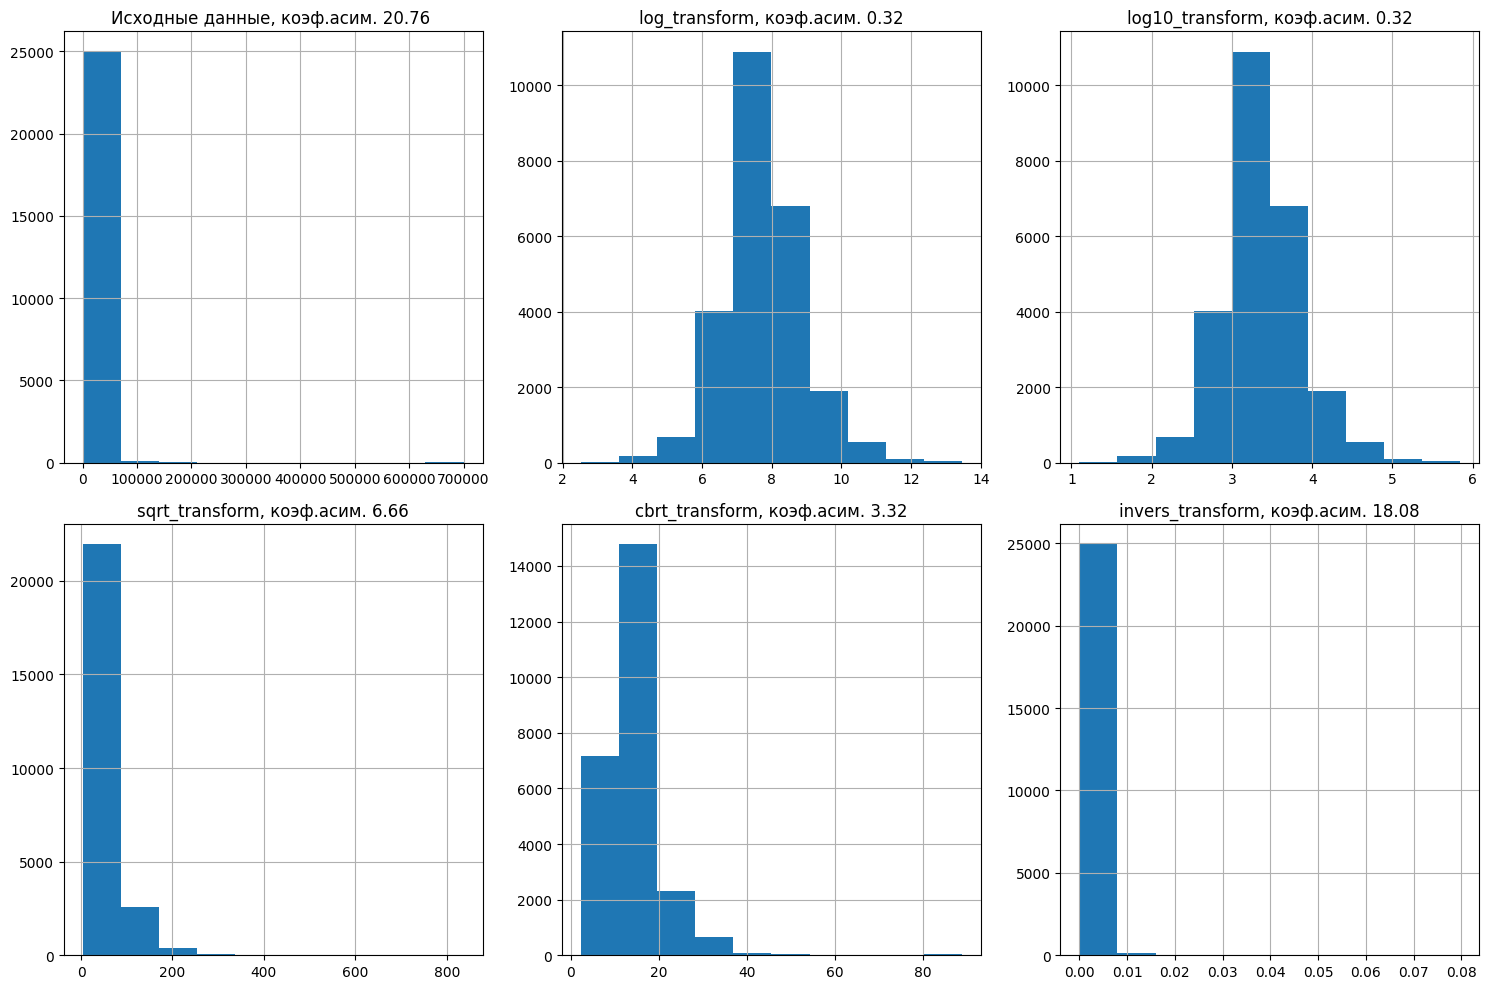

Исходные данные: 20.759174284894236
log_transform: 0.31641885489280985
log10_transform: 0.31641885489281
sqrt_transform: 6.660840610792201
cbrt_transform: 3.3201812496721153
invers_transform: 18.075473717716665

Трансформация за 2016 год


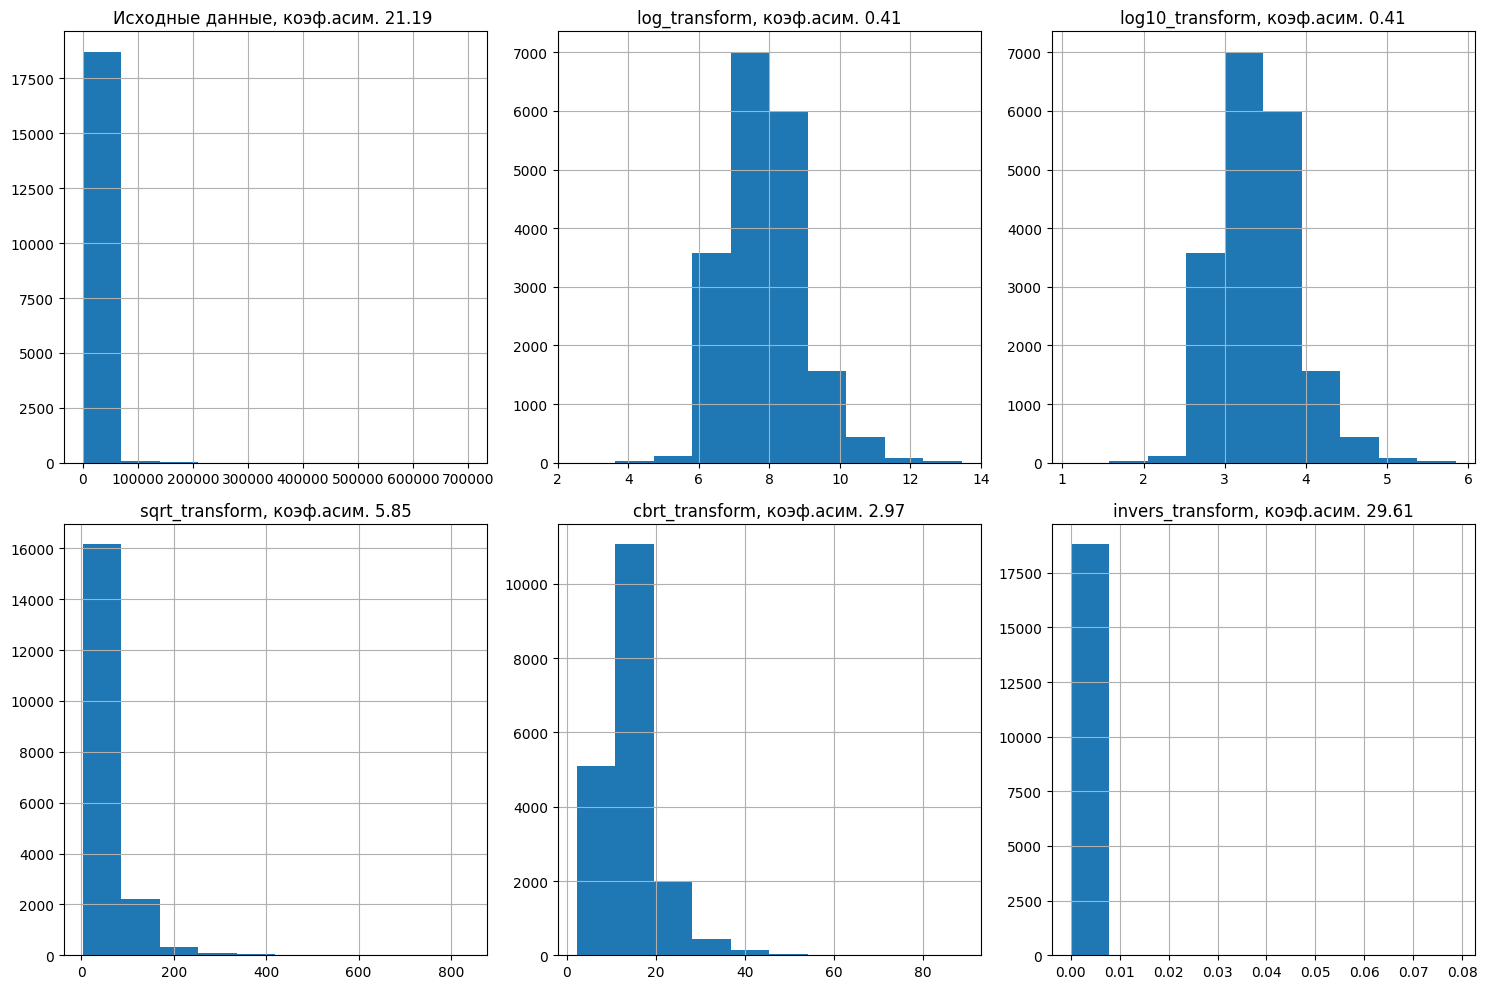

Исходные данные: 21.192220198698667
log_transform: 0.41149295284936965
log10_transform: 0.41149295284936543
sqrt_transform: 5.854668640117746
cbrt_transform: 2.9658165907176635
invers_transform: 29.60745268179835
Критерий Колмогорова - Смирнова 2015: 0.000000e+00
Критерий Колмогорова - Смирнова 2016: 0.000000e+00

t-тест Уэлча: 0.372159


In [5]:
#	Анализ прибыли компании за 2 периода
# Гипотеза о равенстве среднего значения фактической прибыли  в 2015 и в 2016 годах.
# Параметрические критерии для оценки средних значений (для больших выборок > 5000 работает даже при ненормальности)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from scipy.stats import kstest, norm
from scipy.stats import ttest_ind

Orders = pd.read_excel('Логистическая_компания.xlsx', sheet_name='Исходные_данные')
group_2015 = Orders[Orders['Год'] == 2015]['Факт прибыль'].values
group_2016 = Orders[Orders['Год'] == 2016]['Факт прибыль'].values
# Проверка распределения фактической прибыли за 2015 и за 2016 годы на нормальность
# Длина выборки > 5000 - критерий Колмогорова - Смирнова
# Стандартизируем данные
group_2015_norm = (group_2015 - np.mean(group_2015)) / np.std(group_2015)
group_2016_norm = (group_2016 - np.mean(group_2016)) / np.std(group_2016)

# Функция для оценки нормальности распределения по Критерию Колмогорова - Смирнова
def norma(df1,df2):
    print(f"Критерий Колмогорова - Смирнова 2015: {kstest(df1, 'norm').pvalue:.6e}")
    print(f"Критерий Колмогорова - Смирнова 2016: {kstest(df2, 'norm').pvalue:.6e}")

# Функция параметрического t-теста Уэлча (проверка равенства средних)
def test(df1,df2):
    print(f"\nt-тест Уэлча: {ttest_ind(df1, df2, equal_var=False).pvalue:.6f}")

# Функция трансформации
def transform(df):
    df = pd.Series(df)
    # Логарифмическое преобразование
    log_transform = np.log(df)
    # Десятичный логарифм от данных
    log10_transform = np.log10(df)
    # Преобразование квадратного корня
    sqrt_transform = np.sqrt(df)
    # Преобразование кубического корня
    cbrt_transform = np.cbrt(df)
    # Преобразование обратная дробь
    invers_transform = 1/df
    # Визуализация
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes[0, 0].set_title(f'Исходные данные, коэф.асим. {df.skew():.2f} ')
    df.hist(bins=10, ax=axes[0, 0])
    log_transform.hist(bins=10, ax=axes[0, 1])
    axes[0, 1].set_title(f'log_transform, коэф.асим. {log_transform.skew():.2f}')
    log10_transform.hist(bins=10, ax=axes[0, 2])
    axes[0, 2].set_title(f'log10_transform, коэф.асим. {log10_transform.skew():.2f}')
    sqrt_transform.hist(bins=10, ax=axes[1, 0])
    axes[1, 0].set_title(f'sqrt_transform, коэф.асим. {sqrt_transform.skew():.2f}')
    cbrt_transform.hist(bins=10, ax=axes[1, 1])
    axes[1, 1].set_title(f'cbrt_transform, коэф.асим. {cbrt_transform.skew():.2f}')
    invers_transform.hist(bins=10, ax=axes[1, 2])
    axes[1, 2].set_title(f'invers_transform, коэф.асим. {invers_transform.skew():.2f}')
    plt.tight_layout()
    plt.show()
    print('Исходные данные:', df.skew())
    print('log_transform:', log_transform.skew())
    print('log10_transform:', log10_transform.skew())
    print('sqrt_transform:', sqrt_transform.skew())
    print('cbrt_transform:', cbrt_transform.skew())
    print('invers_transform:', invers_transform.skew())

# Оценка нормальности распределения
norma(group_2015_norm,group_2016_norm)
# p=0 < a=0.05 - гипотезу о нормальности выборки фактической прибыли  за 2015 отвергаем на уровне значимости α = 0.05.
# p=0 < a=0.05 - гипотезу о нормальности выборки фактической прибыли  за 2016 отвергаем на уровне значимости α = 0.05.

# Трансформируем данные
print("\nТрансформация за 2015 год")
transform(group_2015)
print("\nТрансформация за 2016 год")
transform(group_2016)
# Логарифмическое преобразование (log) лучше всего трансформировало данные - используем его
group_2015_log = np.log(group_2015)
group_2016_log = np.log(group_2016)

# Проверяем нормальность после логарифмического преобразования
norma(group_2015_log, group_2016_log)
# p=0 < a=0.05 - гипотезу о нормальности выборки фактической прибыли  за 2015 отвергаем на уровне значимости α = 0.05.
# p=0 < a=0.05 - гипотезу о нормальности выборки фактической прибыли  за 2016 отвергаем на уровне значимости α = 0.05.
# После трансформации распределение не стало нормальным (p ≈ 0), поэтому повторный t-тест Уэлчана о равенство средних после трансформации проводить не стоит.

# Данные не нормальны используем параметрический t-тест Уэлча (для больших выборок > 5000 работает даже при ненормальности)
test(group_2015, group_2016)
# p-value 0.372 > 0.05 – не отвергаем гипотезу о равенстве средних значения фактической прибыли в 2015 и в 2016 годах на уровне значимости α = 0.05.
# Вывод: Средняя фактическая прибыль в 2015 и 2016 годах статистически значимо не различаются.

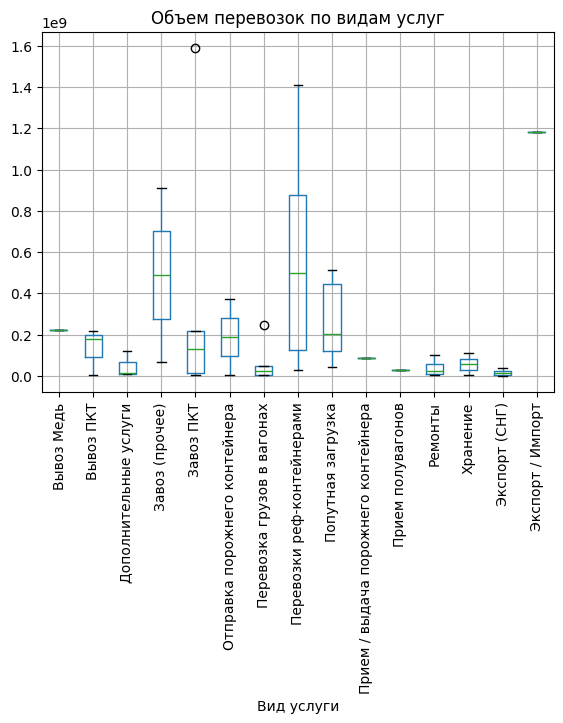

Критерий Kruskal-Wallis p-value: 0.071982



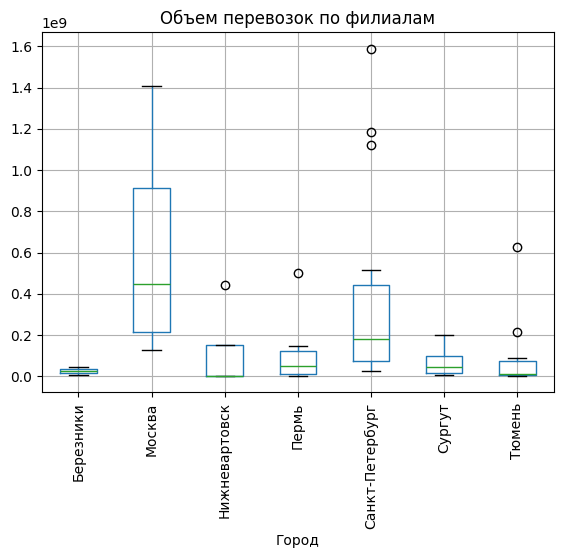

Критерий Kruskal-Wallis p-value: 0.006928

Dunn's test для филиалов по объемам перевозок - p-values:

                 Березники    Москва  Нижневартовск     Пермь  Санкт-Петербург    Сургут    Тюмень
Березники         1.000000  0.252162       1.000000  1.000000         0.690150  1.000000  1.000000
Москва            0.252162  1.000000       0.198550  0.547136         1.000000  0.701511  0.067274
Нижневартовск     1.000000  0.198550       1.000000  1.000000         0.526207  1.000000  1.000000
Пермь             1.000000  0.547136       1.000000  1.000000         1.000000  1.000000  1.000000
Санкт-Петербург   0.690150  1.000000       0.526207  1.000000         1.000000  1.000000  0.118391
Сургут            1.000000  0.701511       1.000000  1.000000         1.000000  1.000000  1.000000
Тюмень            1.000000  0.067274       1.000000  1.000000         0.118391  1.000000  1.000000


In [59]:
#	Анализ распределения объема перевозок  для всех видов услуг и филиалов
# Гипотеза о независимости объема перевозок по видам услуг
import pandas as pd
from scipy.stats import kruskal
import matplotlib.pyplot as plt
import scikit_posthocs as sp
Orders = pd.read_excel('Логистическая_компания.xlsx', sheet_name='Рынок')
# Визуализация данных
Orders.boxplot(column = 'Объем перевозок', by = 'Вид услуги', rot=90)
plt.suptitle('')
plt.title('Объем перевозок по видам услуг')
plt.show()
# Выбросы есть - скорее данные не нормальны
# Используем критерий Kruskal-Wallis (не требует нормальности и устойчив к выбросам - ANOVA нельзя)
groups = [group['Объем перевозок'].values for name, group in Orders.groupby('Вид услуги')]
print(f"Критерий Kruskal-Wallis p-value: {kruskal(*groups).pvalue:.6f}\n")
# p-value 0.07 > 0.05 – не отвергаем гипотезу об одинаковом распределении объема перевозок по всем видам услуг на уровне значимости α = 0.05.

# Гипотеза о независимости объема перевозок по филиалам
# Визуализация данных
Orders.boxplot(column = 'Объем перевозок', by = 'Город', rot=90)
plt.suptitle('')
plt.title('Объем перевозок по филиалам')
plt.show()
# Выбросы есть - скорее данные не нормальны
# Используем критерий Kruskal-Wallis (не требует нормальности и устойчив к выбросам - ANOVA нельзя)
groups = [group['Объем перевозок'].values for name, group in Orders.groupby('Город')]
print(f"Критерий Kruskal-Wallis p-value: {kruskal(*groups).pvalue:.6f}")
# p-value 0.007 < 0.05 – отвергаем гипотезу об одинаковом распределении объема перевозок по всем филиалам на уровне значимости α = 0.05.
# Выявим филиалы, статистически значимо отличающиеся по объёму перевозок
# Используем Dunn's test
dunn_result = sp.posthoc_dunn(
    Orders,
    val_col='Объем перевозок',
    group_col='Город',
    p_adjust='bonferroni'
)
print("\nDunn's test для филиалов по объемам перевозок - p-values:\n")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 20)
print(dunn_result)
# Ни одна пара филиал-объем перевозок не показала p < 0.05
# Kruskal-Wallis тест выявил статистически значимые различия между филиалами по объему перевозок (p = 0.007).
# Однако попарные сравнения (Dunn's test с поправкой Бонферрони) не обнаружили значимых различий филиалов по объемам перевозок на уровне значимости α = 0.05.
# Наиболее близки к значимости различия между Москвой и Тюменью (p = 0.067): по боксплоту видно, что медиана Москвы больше, чем у Тюмени
# Отсутствие значимых парных различий при общем значимом результате Kruskal-Wallis может быть связано с:
# небольшим размером выборки (n = 50)
# высокой консервативностью поправки Бонферрони
# различиями, распределенными между несколькими группами


In [38]:
pip install scikit-posthocs
